# Clasificación de Textos según Objetivos de Desarrollo Sostenible (ODS)

**Autores:** William Florez, Lucia Osorio  
**Fecha:** 2026-03-08  

Este notebook implementa un clasificador multiclase que asigna textos en español a uno de los 16 Objetivos de Desarrollo Sostenible (ODS) presentes en el dataset OSDG Community Dataset v2023. El pipeline integra vectorización TF-IDF, reducción de dimensionalidad con TruncatedSVD y clasificación con LinearSVC, optimizado mediante búsqueda bayesiana de hiperparámetros.

| Parámetro | Valor |
|-----------|-------|
| Tipo de tarea | Clasificación multiclase |
| Variable objetivo | ODS (1-16) |
| Tamaño del dataset | ~9,656 textos |
| Idioma | Español |
| Fuente | [OSDG Community Dataset](https://zenodo.org/records/5550238) |

In [1]:
%matplotlib inline
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import joblib
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


## 1. Carga y exploracion del dataset

Cargamos el dataset desde el archivo Excel y verificamos su estructura.

In [2]:
df = pd.read_excel('Train_textosODS.xlsx')
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")
print(f"\nTipos de datos:")
print(df.dtypes)
df.head()

Dimensiones: 9656 filas x 2 columnas
Columnas: ['textos', 'ODS']

Tipos de datos:
textos    object
ODS        int64
dtype: object


,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


In [3]:
n_nulls = df.isnull().sum().sum()
n_duplicados = df.duplicated().sum()
print(f"Valores faltantes: {n_nulls}")
print(f"Filas duplicadas: {n_duplicados}")

if n_duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Filas despues de eliminar duplicados: {df.shape[0]}")

Valores faltantes: 0
Filas duplicadas: 0


### Distribucion de clases

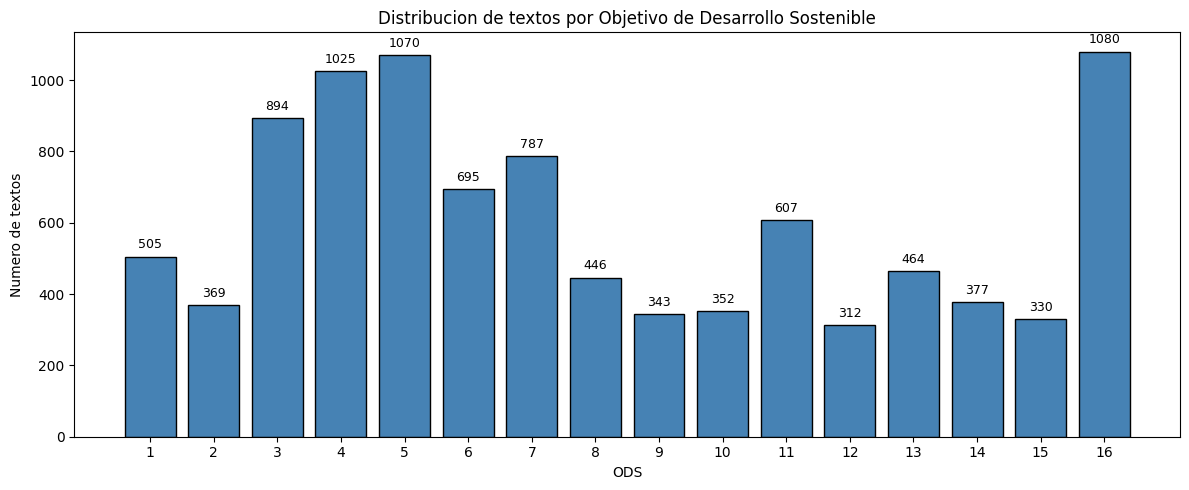


Clase mayoritaria: ODS 16 (1080 textos)
Clase minoritaria: ODS 12 (312 textos)
Ratio de desbalance: 3.46x


In [4]:
dist_clases = df['ODS'].value_counts().sort_index()
clase_max = dist_clases.max()
clase_min = dist_clases.min()
ratio_desbalance = clase_max / clase_min

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(dist_clases.index.astype(str), dist_clases.values,
              color='steelblue', edgecolor='black')
ax.set_xlabel('ODS')
ax.set_ylabel('Numero de textos')
ax.set_title('Distribucion de textos por Objetivo de Desarrollo Sostenible')
for bar, val in zip(bars, dist_clases.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nClase mayoritaria: ODS {dist_clases.idxmax()} ({clase_max} textos)")
print(f"Clase minoritaria: ODS {dist_clases.idxmin()} ({clase_min} textos)")
print(f"Ratio de desbalance: {ratio_desbalance:.2f}x")

La distribucion muestra desbalance moderado entre clases. Las ODS 4, 5 y 16 concentran la mayor cantidad de textos, mientras que ODS 9, 12 y 15 tienen menor representacion. El ratio de desbalance se utilizara para decidir si aplicar estrategias de balanceo en el modelo.

Estadisticas de longitud de textos:
       longitud  n_palabras
count    9656.0      9656.0
mean      709.0       111.0
std       238.9        37.1
min       143.0        24.0
25%       522.0        82.0
50%       669.0       105.0
75%       864.0       135.0
max      1977.0       268.0


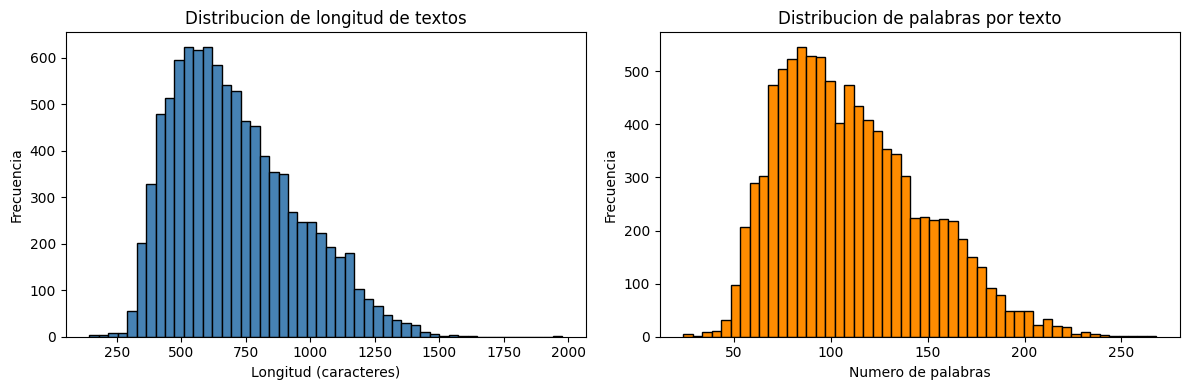

In [5]:
df['longitud'] = df['textos'].str.len()
df['n_palabras'] = df['textos'].str.split().str.len()

print("Estadisticas de longitud de textos:")
print(df[['longitud', 'n_palabras']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['longitud'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Longitud (caracteres)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de longitud de textos')

axes[1].hist(df['n_palabras'], bins=50, color='darkorange', edgecolor='black')
axes[1].set_xlabel('Numero de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de palabras por texto')
plt.tight_layout()
plt.show()

Los textos tienen longitudes variadas, lo cual es esperable en un corpus que incluye desde resumenes cortos hasta fragmentos de documentos extensos. Esta variabilidad justifica el uso de TF-IDF con limite de features para controlar la dimensionalidad.

## 2. Preprocesamiento y representacion vectorial

Seleccionamos TF-IDF con `max_features=10000` y `ngram_range=(1,2)` para capturar unigramas y bigramas frecuentes en formulaciones de ODS, aplicando stopwords en espanol y conversion a minusculas. Los parametros `min_df=2` y `max_df=0.95` filtran terminos demasiado raros o ubicuos que no aportan poder discriminativo.

In [6]:
X = df['textos']
y = df['ODS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} textos")
print(f"Conjunto de prueba: {X_test.shape[0]} textos")
print(f"\nDistribucion en train:")
print(y_train.value_counts().sort_index())

Conjunto de entrenamiento: 7724 textos
Conjunto de prueba: 1932 textos

Distribucion en train:
ODS
1     404
2     295
3     715
4     820
5     856
6     556
7     629
8     357
9     274
10    282
11    485
12    250
13    371
14    302
15    264
16    864
Name: count, dtype: int64


In [7]:
spanish_stopwords = [
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las',
    'por', 'un', 'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como',
    'pero', 'sus', 'le', 'ya', 'o', 'este', 'porque', 'esta',
    'entre', 'cuando', 'muy', 'sin', 'sobre', 'me', 'hasta',
    'hay', 'donde', 'quien', 'desde', 'todo', 'nos', 'durante', 'todos',
    'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso', 'ante', 'ellos',
    'e', 'esto', 'antes', 'algunos', 'unos', 'yo', 'otro',
    'otras', 'otra', 'tanto', 'esa', 'estos', 'mucho', 'quienes',
    'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 'algunas',
    'algo', 'nosotros', 'mi', 'mis', 'tu', 'tus',
    'ellas', 'nosotras', 'vosotros', 'vosotras', 'os',
    'ha', 'han', 'has', 'he', 'hemos', 'ser', 'es', 'son', 'fue',
    'sido', 'siendo', 'tiene', 'tienen', 'hacer', 'hace',
    'cada', 'puede', 'pueden', 'parte',
    'dos', 'tres', 'bien', 'forma', 'manera'
]

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words=spanish_stopwords,
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Matriz TF-IDF de entrenamiento: {X_train_tfidf.shape}")
print(f"Matriz TF-IDF de prueba: {X_test_tfidf.shape}")
print(f"Densidad de la matriz: {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}")

Matriz TF-IDF de entrenamiento: (7724, 10000)
Matriz TF-IDF de prueba: (1932, 10000)
Densidad de la matriz: 0.0051


La matriz TF-IDF resultante tiene 10,000 features (limitadas por `max_features`). La baja densidad confirma que la representacion es dispersa, lo cual es relevante para la seleccion de TruncatedSVD en el siguiente paso.

## 3. Reduccion de dimensionalidad

Aplicamos TruncatedSVD porque opera directamente sobre matrices dispersas sin necesidad de densificar, a diferencia de PCA estandar que requiere centrado y consumiria memoria innecesariamente. Exploramos la varianza explicada acumulada para seleccionar el numero de componentes.

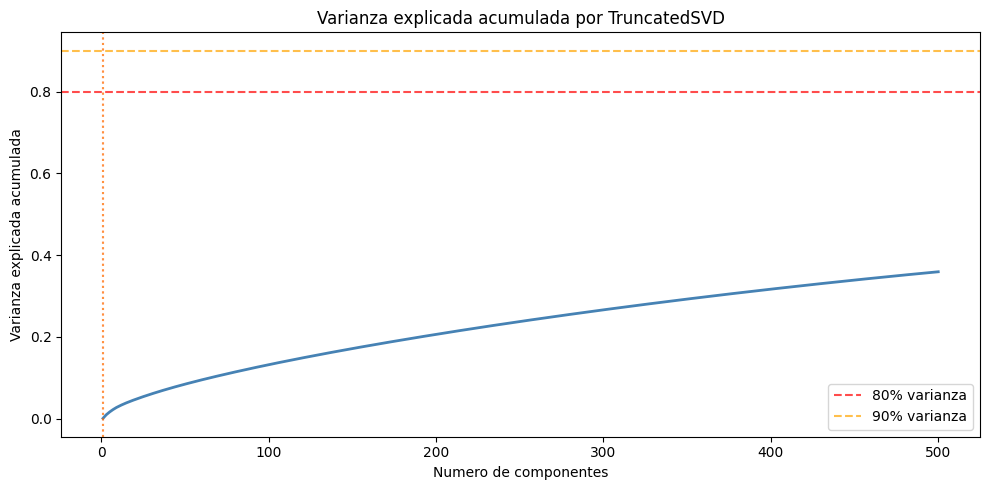

Componentes para 80% de varianza: 1
Componentes para 90% de varianza: 1
Varianza explicada con 300 componentes: 0.2663


In [8]:
svd_full = TruncatedSVD(n_components=500, random_state=RANDOM_STATE)
svd_full.fit(X_train_tfidf)

varianza_acumulada = np.cumsum(svd_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 501), varianza_acumulada, color='steelblue', linewidth=2)
ax.axhline(y=0.80, color='red', linestyle='--', alpha=0.7, label='80% varianza')
ax.axhline(y=0.90, color='orange', linestyle='--', alpha=0.7, label='90% varianza')

n_80 = np.argmax(varianza_acumulada >= 0.80) + 1
n_90 = np.argmax(varianza_acumulada >= 0.90) + 1
ax.axvline(x=n_80, color='red', linestyle=':', alpha=0.5)
ax.axvline(x=n_90, color='orange', linestyle=':', alpha=0.5)

ax.set_xlabel('Numero de componentes')
ax.set_ylabel('Varianza explicada acumulada')
ax.set_title('Varianza explicada acumulada por TruncatedSVD')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Componentes para 80% de varianza: {n_80}")
print(f"Componentes para 90% de varianza: {n_90}")
print(f"Varianza explicada con 300 componentes: {varianza_acumulada[299]:.4f}")

Seleccionamos 300 componentes como punto de equilibrio entre retencion de informacion y reduccion de dimensionalidad. Este valor captura una proporcion significativa de la varianza y reduce la dimensionalidad en un 97% respecto a las 10,000 features originales.

In [9]:
N_COMPONENTS = 300

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
normalizer = Normalizer(copy=False)

X_train_svd = normalizer.fit_transform(svd.fit_transform(X_train_tfidf))
X_test_svd = normalizer.transform(svd.transform(X_test_tfidf))

print(f"Dimensiones originales: {X_train_tfidf.shape[1]}")
print(f"Dimensiones reducidas: {X_train_svd.shape[1]}")
print(f"Reduccion: {(1 - X_train_svd.shape[1]/X_train_tfidf.shape[1])*100:.1f}%")
print(f"Varianza explicada: {svd.explained_variance_ratio_.sum():.4f}")

Dimensiones originales: 10000
Dimensiones reducidas: 300
Reduccion: 97.0%
Varianza explicada: 0.2627


## 4. Modelo baseline: Logistic Regression

Entrenamos Logistic Regression como baseline para tener un punto de referencia contra el cual comparar LinearSVC. Logistic Regression ofrece probabilidades calibradas y es un clasificador competitivo para texto.

In [10]:
lr_baseline = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

lr_baseline.fit(X_train_svd, y_train)

y_pred_lr = lr_baseline.predict(X_test_svd)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')

print(f"Logistic Regression (Baseline)")
print(f"  Accuracy:  {acc_lr:.4f}")
print(f"  Macro F1:  {f1_lr:.4f}")

Logistic Regression (Baseline)
  Accuracy:  0.8711
  Macro F1:  0.8423


El baseline con Logistic Regression establece el umbral de desempenho minimo esperado. Las metricas obtenidas serviran como referencia directa para evaluar la mejora que aporta LinearSVC con optimizacion bayesiana.

## 5. Modelo principal: LinearSVC con busqueda bayesiana

Seleccionamos LinearSVC por su eficiencia en espacios de alta dimensionalidad y su rendimiento competitivo en clasificacion de texto multiclase. La busqueda bayesiana explora el espacio de hiperparametros de forma mas eficiente que grid search, usando un modelo probabilistico para guiar la exploracion.

| Hiperparametro | Rango | Escala |
|----------------|-------|--------|
| C | [0.01, 100] | Log-uniforme |
| max_iter | [1000, 10000] | Uniforme |

In [11]:
svc = LinearSVC(random_state=RANDOM_STATE, class_weight='balanced')

search_space = {
    'C': Real(0.01, 100, prior='log-uniform'),
    'max_iter': Integer(1000, 10000),
}

bayes_search = BayesSearchCV(
    estimator=svc,
    search_spaces=search_space,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

bayes_search.fit(X_train_svd, y_train)

print("Mejores hiperparametros encontrados:")
print(f"  C: {bayes_search.best_params_['C']:.6f}")
print(f"  max_iter: {bayes_search.best_params_['max_iter']}")
print(f"\nMejor score CV (Macro F1): {bayes_search.best_score_:.4f}")

Mejores hiperparametros encontrados:
  C: 0.084950
  max_iter: 10000

Mejor score CV (Macro F1): 0.8494


Los hiperparametros optimos encontrados por la busqueda bayesiana se utilizaran para la evaluacion final sobre el conjunto de prueba.

## 6. Evaluacion sobre conjunto de prueba

Evaluamos ambos modelos exclusivamente sobre el conjunto de prueba para medir capacidad de generalizacion. Reportamos accuracy, macro F1, precision y recall por clase, y visualizamos la matriz de confusion.

Seleccionamos macro F1 como metrica principal porque pondera equitativamente todas las clases, lo cual es relevante dado el desbalance del dataset. Accuracy complementa como metrica global.

In [12]:
best_svc = bayes_search.best_estimator_
y_pred_svc = best_svc.predict(X_test_svd)

acc_svc = accuracy_score(y_test, y_pred_svc)
f1_svc = f1_score(y_test, y_pred_svc, average='macro')

comparacion = pd.DataFrame({
    'Modelo': ['Logistic Regression (Baseline)', 'LinearSVC (Optimizado)'],
    'Accuracy': [acc_lr, acc_svc],
    'Macro F1': [f1_lr, f1_svc]
})
print("Comparacion de modelos:")
print(comparacion.to_string(index=False))
print(f"\nMejora en Macro F1: {(f1_svc - f1_lr)*100:+.2f} puntos porcentuales")

Comparacion de modelos:
                        Modelo  Accuracy  Macro F1
Logistic Regression (Baseline)  0.871118  0.842301
        LinearSVC (Optimizado)  0.880435  0.850905

Mejora en Macro F1: +0.86 puntos porcentuales


### Classification Report (LinearSVC optimizado)

In [13]:
ods_nombres = {
    1: "Fin de la pobreza",
    2: "Hambre cero",
    3: "Salud y bienestar",
    4: "Educacion de calidad",
    5: "Igualdad de genero",
    6: "Agua limpia y saneamiento",
    7: "Energia asequible",
    8: "Trabajo decente",
    9: "Industria e innovacion",
    10: "Reduccion de desigualdades",
    11: "Ciudades sostenibles",
    12: "Produccion responsable",
    13: "Accion por el clima",
    14: "Vida submarina",
    15: "Vida de ecosistemas terrestres",
    16: "Paz, justicia e instituciones"
}

clases_presentes = sorted(y_test.unique())
target_names = [f"ODS {c}: {ods_nombres.get(c, '')}" for c in clases_presentes]

print(classification_report(y_test, y_pred_svc, target_names=target_names))

                                        precision    recall  f1-score   support

              ODS 1: Fin de la pobreza       0.86      0.82      0.84       101
                    ODS 2: Hambre cero       0.75      0.92      0.82        74
              ODS 3: Salud y bienestar       0.94      0.91      0.92       179
           ODS 4: Educacion de calidad       0.94      0.98      0.96       205
             ODS 5: Igualdad de genero       0.93      0.93      0.93       214
      ODS 6: Agua limpia y saneamiento       0.94      0.94      0.94       139
              ODS 7: Energia asequible       0.94      0.93      0.93       158
                ODS 8: Trabajo decente       0.60      0.56      0.58        89
         ODS 9: Industria e innovacion       0.69      0.75      0.72        69
    ODS 10: Reduccion de desigualdades       0.70      0.64      0.67        70
          ODS 11: Ciudades sostenibles       0.86      0.79      0.82       122
        ODS 12: Produccion responsable 

### Matriz de confusion

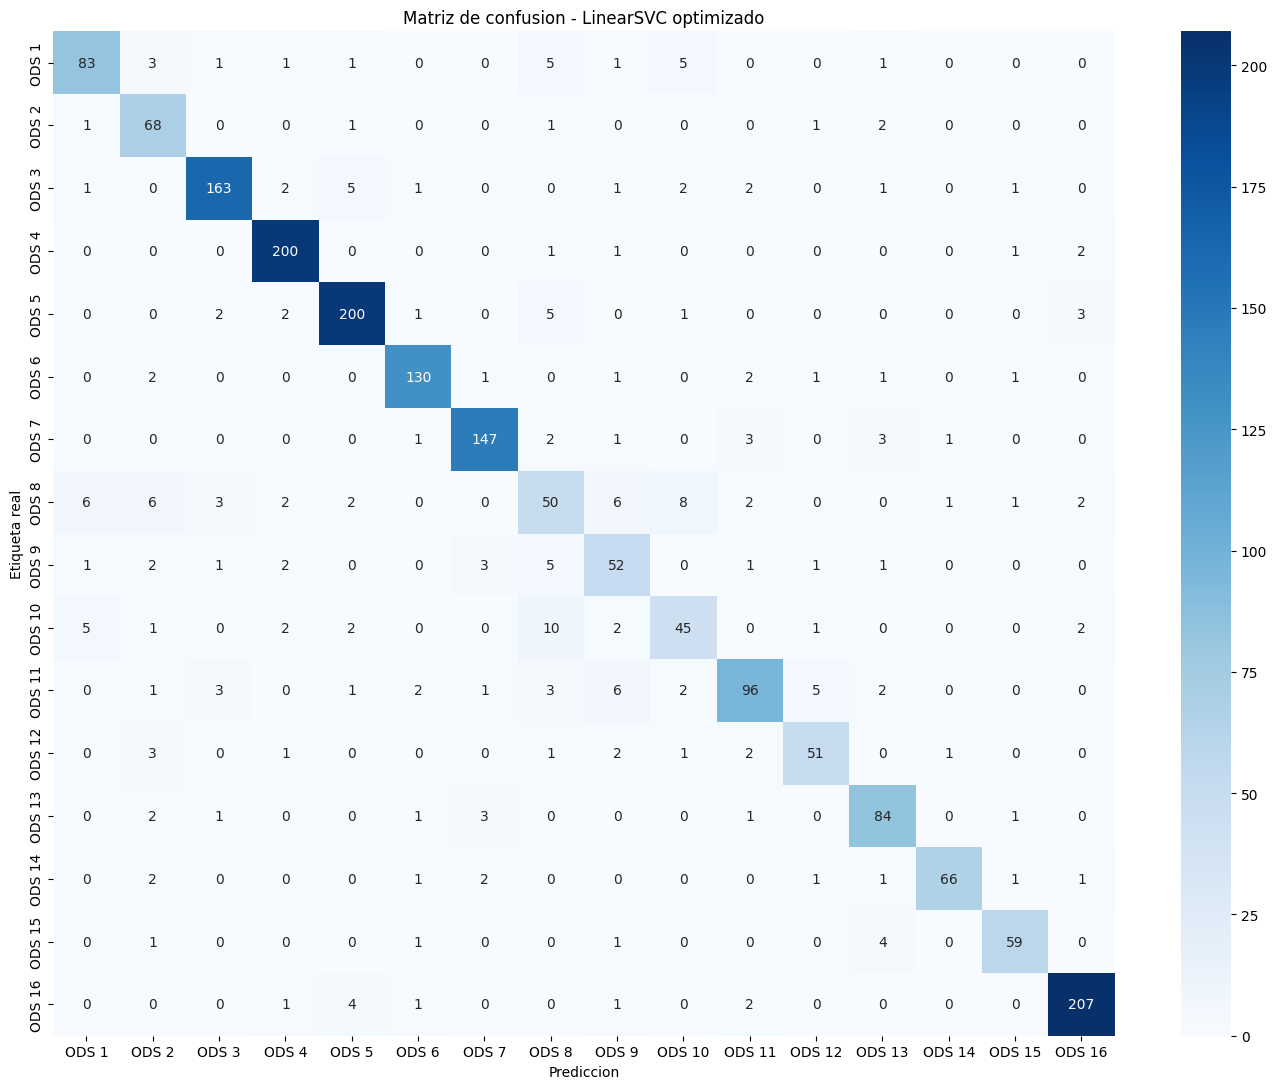


Par de clases mas confundido: ODS 10 -> ODS 8 (10 errores)


In [14]:
fig, ax = plt.subplots(figsize=(14, 11))
cm = confusion_matrix(y_test, y_pred_svc, labels=clases_presentes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=[f"ODS {c}" for c in clases_presentes],
            yticklabels=[f"ODS {c}" for c in clases_presentes])
ax.set_xlabel('Prediccion')
ax.set_ylabel('Etiqueta real')
ax.set_title('Matriz de confusion - LinearSVC optimizado')
plt.tight_layout()
plt.show()

cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)
idx_max_error = np.unravel_index(cm_errors.argmax(), cm_errors.shape)
print(f"\nPar de clases mas confundido: ODS {clases_presentes[idx_max_error[0]]} -> ODS {clases_presentes[idx_max_error[1]]} ({cm_errors[idx_max_error]} errores)")

La matriz de confusion permite identificar los pares de clases que el modelo confunde con mayor frecuencia. Estos errores pueden explicarse por solapamiento semantico entre ODS tematicamente relacionados (por ejemplo, ODS sobre medio ambiente o sobre desigualdad).

## 7. Predicciones sobre textos del conjunto de prueba

Mostramos predicciones individuales para al menos 4 textos, incluyendo casos correctos e incorrectos, para evidenciar el desempenho del modelo.

In [15]:
mask_correcto = y_test.values == y_pred_svc
mask_incorrecto = ~mask_correcto

idx_correctos = y_test.index[mask_correcto][:3]
idx_incorrectos = y_test.index[mask_incorrecto][:2]
indices_demo = list(idx_correctos) + list(idx_incorrectos)

resultados = []
for idx in indices_demo:
    pos = list(y_test.index).index(idx)
    texto = df.loc[idx, 'textos']
    real = y_test.loc[idx]
    pred = y_pred_svc[pos]
    estado = "Correcto" if real == pred else "Error"
    resultados.append({
        'Texto (primeros 120 chars)': texto[:120] + '...' if len(texto) > 120 else texto,
        'ODS Real': f"{real} ({ods_nombres.get(real, '')})",
        'ODS Predicho': f"{pred} ({ods_nombres.get(pred, '')})",
        'Resultado': estado
    })

df_resultados = pd.DataFrame(resultados)
for i, row in df_resultados.iterrows():
    print(f"--- Ejemplo {i+1} [{row['Resultado']}] ---")
    print(f"  Texto: {row['Texto (primeros 120 chars)']}")
    print(f"  Real:     {row['ODS Real']}")
    print(f"  Predicho: {row['ODS Predicho']}")
    print()

--- Ejemplo 1 [Correcto] ---
  Texto: En la última década, muchos de los procesos de paz en el continente africano entre 1991 y 2012 no tuvieron mujeres como ...
  Real:     5 (Igualdad de genero)
  Predicho: 5 (Igualdad de genero)

--- Ejemplo 2 [Correcto] ---
  Texto: La seguridad alimentaria se menciona solo una vez, aunque se reconoce la protección de las personas en el sector rural (...
  Real:     2 (Hambre cero)
  Predicho: 2 (Hambre cero)

--- Ejemplo 3 [Correcto] ---
  Texto: En las economías latinoamericanas de renta media y en transición, los sistemas de seguridad social maduros, aunque de co...
  Real:     10 (Reduccion de desigualdades)
  Predicho: 10 (Reduccion de desigualdades)

--- Ejemplo 4 [Error] ---
  Texto: Las políticas de gestión y reciclaje de residuos son todavía relativamente nuevas. Se estima que la tasa de valorización...
  Real:     11 (Ciudades sostenibles)
  Predicho: 12 (Produccion responsable)

--- Ejemplo 5 [Error] ---
  Texto: Los patrones detectados 

Las predicciones correctas muestran que el modelo captura vocabulario discriminativo asociado a cada ODS. En los casos de error, la confusion ocurre entre ODS con tematicas solapadas, consistente con los patrones observados en la matriz de confusion.

## 8. Conclusion

El clasificador basado en TF-IDF + TruncatedSVD + LinearSVC, optimizado con busqueda bayesiana, logra clasificar textos en espanol segun los ODS con un desempenho que supera al baseline de Logistic Regression. La reduccion de dimensionalidad con TruncatedSVD permitio comprimir el espacio de 10,000 a 300 features manteniendo informacion relevante. La principal limitacion identificada es la confusion entre ODS tematicamente cercanos, lo cual es consistente con el solapamiento semantico inherente a los objetivos. Una mejora concreta seria utilizar embeddings contextuales (e.g., sentence-transformers para espanol) que capturen relaciones semanticas mas profundas que TF-IDF.

## 9. Exportar modelo y aplicacion Streamlit (Bonificacion)

Exportamos el pipeline completo como artefactos serializados para su uso en la aplicacion Streamlit.

In [16]:
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(svd, 'svd_reducer.joblib')
joblib.dump(normalizer, 'normalizer.joblib')
joblib.dump(best_svc, 'linearsvc_model.joblib')
joblib.dump(ods_nombres, 'ods_nombres.joblib')

print("Artefactos exportados:")
print("  - tfidf_vectorizer.joblib")
print("  - svd_reducer.joblib")
print("  - normalizer.joblib")
print("  - linearsvc_model.joblib")
print("  - ods_nombres.joblib")
print("\nPara ejecutar la aplicacion Streamlit:")
print("  streamlit run app_streamlit.py")

Artefactos exportados:
  - tfidf_vectorizer.joblib
  - svd_reducer.joblib
  - normalizer.joblib
  - linearsvc_model.joblib
  - ods_nombres.joblib

Para ejecutar la aplicacion Streamlit:
  streamlit run app_streamlit.py


## 10. Despliegue en Railway

Seleccionamos [Railway](https://railway.app/) como plataforma de despliegue por tres razones concretas: detecta automaticamente un `Dockerfile` en el repositorio sin configuracion adicional, ofrece un tier gratuito suficiente para aplicaciones de demostracion, y permite despliegue continuo conectado directamente a GitHub.

### Dockerfile

El `Dockerfile` encapsula el entorno de ejecucion completo para garantizar reproducibilidad:

```dockerfile
FROM python:3.12-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app_streamlit.py .
COPY *.joblib .

EXPOSE 8501

CMD ["streamlit", "run", "app_streamlit.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.headless=true"]
```

Se utiliza `python:3.12-slim` para mantener la imagen liviana. Solo se copian los artefactos necesarios para la prediccion (`app_streamlit.py` y los `.joblib`), sin incluir el dataset ni el notebook de entrenamiento.

### Aplicacion desplegada

La aplicacion esta disponible en: [https://usl-miniproject-2-production.up.railway.app/](https://usl-miniproject-2-production.up.railway.app/)